In [1]:
import pandas as pd
import numpy as np
import math
import random
from itertools import combinations
import scipy
from scipy.optimize import curve_fit

In [ ]:
n=1600
d=40
w = np.random.uniform(low=0, high=1, size=(3, d))
a = np.random.normal(loc=3, scale=1, size=(d))

In [5]:
def f(x, theta):
    return theta[0] + x[0]*theta[1] + x[1]*theta[2] + x[2]*theta[3]

In [12]:
def getdata(n):
    theta = np.vstack([a, w])
    noise = np.random.uniform(low=-0.5, high=0.5, size = (n, 1))
    X = np.random.normal(size = (n, 3))
    Y = np.empty((n, d))
    for i in range(n):
        Y[i] = f(X[i], theta) + noise[i]
    return X, Y

In [13]:
X, Y = getdata(n)

In [14]:
def get_path(verts):
    row = 0
    col = 0
    outs = []
    for i in range(8):
        if i in verts:
            outs.append(9*row + col + 4)
            row += 1
        else:
            outs.append(9*row + col)
            col += 1
    z = np.zeros(40, dtype=int)
    z[outs] = 1
    return z

feasiblepaths = np.zeros(shape=(70, 40))
i=0
for comb in combinations(range(8), 4):
    feasiblepaths[i] = get_path(comb)
    i += 1

C = np.zeros(shape=(n, 1))
Z = np.zeros(shape=(n, 40))
for i in range(n):
    path = feasiblepaths[np.random.choice(range(70))]
    Z[i] = path
    C[i, 0] = Y[i] @ path

In [17]:
def solmap(y):
    min = np.inf
    out = None
    for z in feasiblepaths:
        if np.dot(y, z) <= min:
            min = np.dot(y, z)
            out = z
    return out

In [18]:
def pgcsubgradient(fx, y, h):
    return (solmap(fx + h * y) - solmap(fx - h * y)) / (2*h)

In [19]:
def derivtheta(f):
    out = np.ones(shape=(4, 40))
    out[1] = f[0]
    out[2] = f[1]
    out[3] = f[2]
    return out

In [ ]:
from tqdm.notebook import tqdm

def stochastic_gradient_descent(X, Z, C, h = 1, lr=0.01, epochs=100):
    theta = np.random.randn(4, 40) # Initialize weights
    truelosses = []
    for epoch in tqdm(range(epochs)):
        # Shuffle data for true stochastic behavior
        indices = np.random.permutation(len(Z))
        trueloss = 0
        for i in indices:
            xi, zi, ci = X[i], Z[i], C[i]
            trueloss += (np.dot(Y[i], solmap(f(xi, theta))) - np.dot(Y[i], solmap(Y[i]))) / len(Z)

            # 2. Use the custom gradient to update weights
            # grad = (derivtheta(f(xi, theta)) * pgcsubgradient(f(xi, theta), thetadr(xi, zi, ci, nuisancef, Gram), h))
            grad = (derivtheta(f(xi, theta)) * pgcsubgradient(f(xi, theta), Y[i], h))

            theta -= lr * grad
        truelosses.append(trueloss)
    return theta, truelosses

  0%|          | 0/200 [00:00<?, ?it/s]

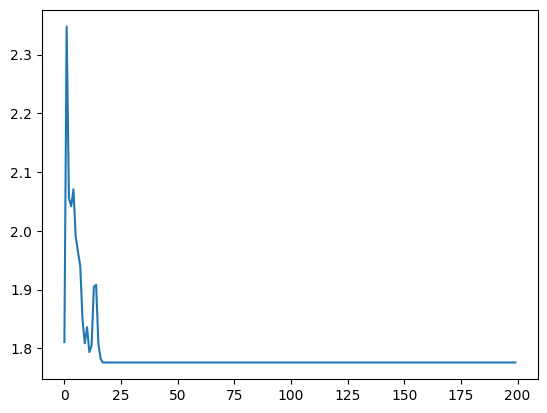

In [75]:
mytheta,truelosses = stochastic_gradient_descent(X, Z, C, h = 1, lr=0.5, epochs=200)
plt.plot(truelosses)

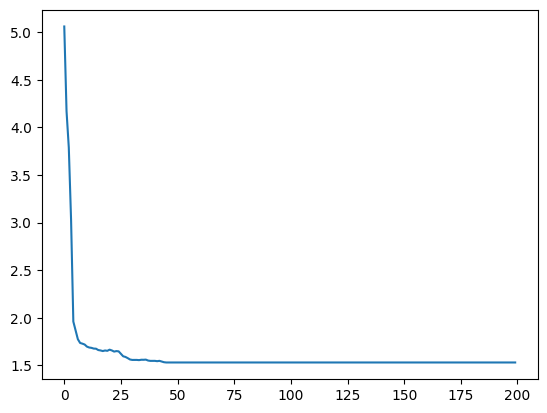

In [43]:
import matplotlib.pyplot as plt
plt.plot(truelosses)

In [76]:
optcost = np.sum([np.dot(Y[i], solmap(Y[i])) for i in range(n)]) / n

In [77]:
optcost

np.float64(21.430928941092947)

In [81]:
mycost = np.sum([np.dot(Y[i], solmap(f(X[i], np.vstack([a, w])))) for i in range(n)]) / n

In [82]:
mycost

np.float64(21.430928941092947)

In [83]:
(mycost - optcost)/optcost

np.float64(0.0)

In [46]:
def residual(w, c, z, x):
    w = w.reshape(4, 40)
    preds = []
    for i in range(len(C)):
        f_val = f(x[i], w)
        preds.append(np.dot(z[i], f_val))
    preds = np.array(preds).reshape(n, 1)
    return (c - preds).flatten()

In [48]:
from scipy.optimize import least_squares

theta0 = np.random.randn(4 * 40)  # initial guess

result = least_squares(residual, theta0, args=(C, Z, X))

theta_opt = result.x.reshape(4, 40)
print("Optimal parameters:", theta_opt)

Optimal parameters: [[ 1.03211146e+01  2.39155678e+00  4.38971896e-01  1.74103591e+00
   6.97156635e+00  1.89801334e-02  1.84887324e-01  5.52666755e-01
   3.23964058e-01  3.47934646e+00  1.66219301e+00  3.17352478e+00
   2.39919150e+00  2.04972112e+00 -3.40440807e-01  1.62505626e+00
   3.35565453e+00  2.28996955e+00  4.44098979e+00  3.74785043e+00
   1.72504203e+00  1.39900131e+00  3.29470569e+00 -2.48341543e-01
   1.99949027e+00  9.06040304e-03 -5.32044513e-01  2.77772280e-01
   2.93406813e+00  1.21316092e+00  3.23242046e+00  7.60453496e-01
   2.79115937e+00  2.24217806e+00  3.52422253e+00  6.49308258e+00
   1.27739011e+00  3.83035505e+00  4.17092930e+00  4.52893194e+00]
 [ 6.61713261e+00  1.02849269e+00 -5.51673799e-01  1.55193198e+00
   3.90231904e+00  3.70882082e-01 -2.96412124e+00 -1.34027069e+00
   6.25786262e-01  2.77725345e+00 -1.74346690e+00  5.49181443e-01
   2.40317813e+00 -1.78573050e+00 -2.43271806e+00 -4.15953579e+00
   1.37883303e+00  2.46857043e+00  2.10697647e+00 -3.55

In [49]:
def nuisancef(x):
    return f(x, theta_opt)

Gram = np.zeros(shape=(40, 40))
for i in range(n):
    
    Gram += Z[i].reshape(40, 1) @ Z[i].reshape(1, 40)
Gram /= n

def thetadm(X, Z, C, f, Sigma):
    return f(X)

def thetadr(X, Z, C, f, Sigma):
    return np.linalg.inv(Sigma + np.identity(40)) @ Z * C

def thetadr(X, Z, C, f, Sigma):
    return f(X) + np.linalg.inv(Sigma + np.identity(40)) @ Z * (C - np.dot(Z, f(X)))

In [ ]:
from tqdm.notebook import tqdm

def stochastic_gradient_descent2(X, Z, C, h = 1, lr=0.01, epochs=100):
    theta = np.random.randn(4, 40) # Initialize weights
    truelosses = []
    for epoch in tqdm(range(epochs)):
        # Shuffle data for true stochastic behavior
        indices = np.random.permutation(len(Z))
        trueloss = 0
        for i in indices:
            xi, zi, ci = X[i], Z[i], C[i]
            trueloss += (np.dot(Y[i], solmap(f(xi, theta))) - np.dot(Y[i], solmap(Y[i]))) / len(Z)

            # 2. Use the custom gradient to update weights
            grad = (derivtheta(f(xi, theta)) * pgcsubgradient(f(xi, theta), thetadr(xi, zi, ci, nuisancef, Gram), h))
            # grad = (derivtheta(f(xi, theta)) * pgcsubgradient(f(xi, theta), Y[i], h))

            theta -= lr * grad
        truelosses.append(trueloss)
    return theta, truelosses

  0%|          | 0/200 [00:00<?, ?it/s]

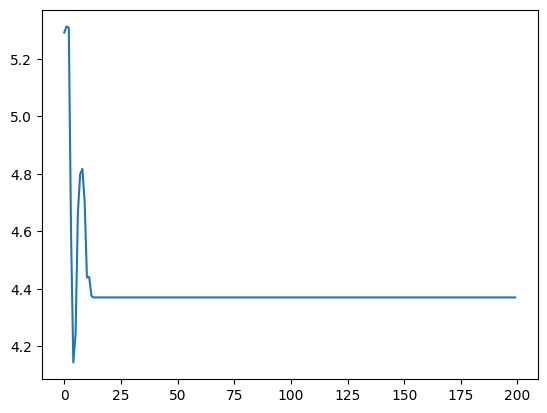

In [64]:
mytheta,truelosses = stochastic_gradient_descent2(X, Z, C, h = 1, lr=0.5, epochs=200)
plt.plot(truelosses)

In [65]:
mycost = np.sum([np.dot(Y[i], solmap(f(X[i], mytheta))) for i in range(n)]) / n

In [66]:
mycost

np.float64(25.800580748057364)